In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
print(df.isna().sum())
print()
print(df["Machine failure"].value_counts())
print()
print(f"Failure rate: {df['Machine failure'].mean()*100:.2f}%")

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [7]:
feature_cols_raw = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

rename_map = {
    "Air temperature [K]": "air_temp_K",
    "Process temperature [K]": "process_temp_K",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_Nm",
    "Tool wear [min]": "tool_wear_min"
}

df = df.rename(columns=rename_map)
feature_cols = list(rename_map.values())

X = df[feature_cols]
y = df["Machine failure"]

print(X.shape, y.shape)
X.describe()

(10000, 5) (10000,)


,air_temp_K,process_temp_K,rotational_speed_rpm,torque_Nm,tool_wear_min
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(f"Train failure rate: {y_train.mean()*100:.2f}%")
print(f"Test failure rate: {y_test.mean()*100:.2f}%")

(8000, 5) (2000, 5)
Train failure rate: 3.39%
Test failure rate: 3.40%


In [9]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)
print("Training done")

Training done


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print()
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 98.70%

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000

Confusion matrix:
[[1927    5]
 [  21   47]]


torque_Nm               0.330805
rotational_speed_rpm    0.226478
tool_wear_min           0.195123
air_temp_K              0.156485
process_temp_K          0.091108
dtype: float32


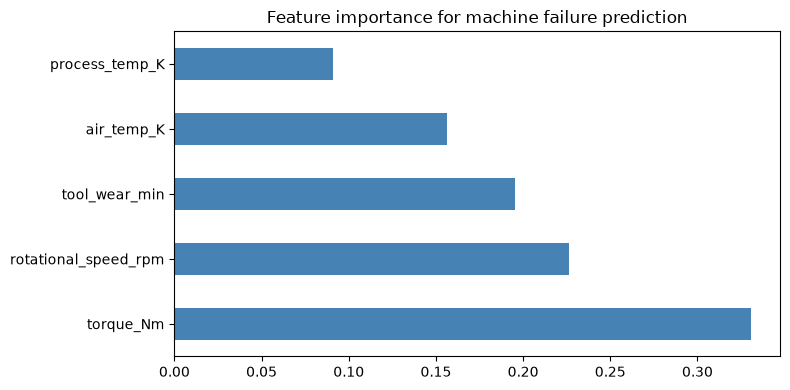

In [11]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature importance for machine failure prediction")
plt.tight_layout()
plt.show()

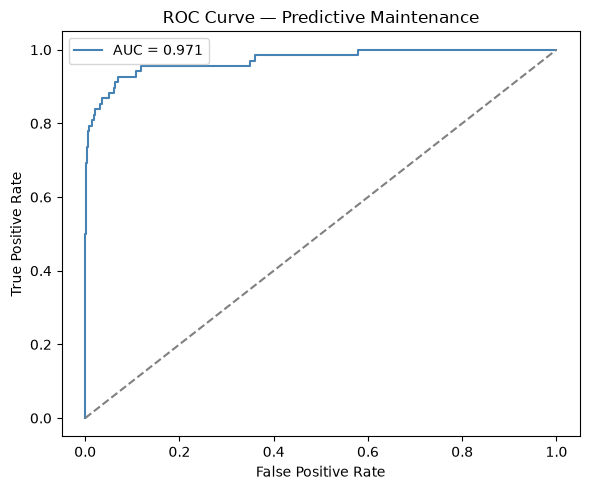

AUC: 0.9714


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="steelblue")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Predictive Maintenance")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

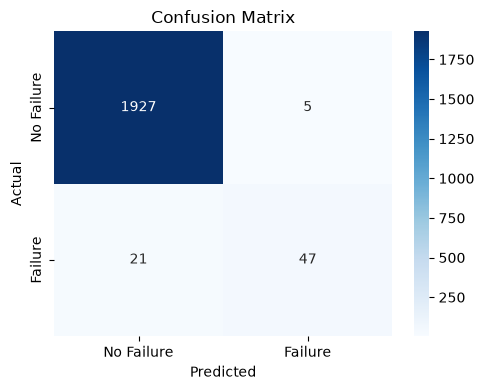

In [13]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Failure", "Failure"], yticklabels=["No Failure", "Failure"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs("../src/models/maintenance", exist_ok=True)
model.save_model("../src/models/maintenance/xgboost_maintenance.json")
print("Model saved")

Model saved


: 